# Prepare Report Artifacts

This notebook builds a `report/` folder that mirrors the `evaluation_results/` layout:

- `report/<run_id>/plain/evaluation_summary.json`
- `report/<run_id>/secure/evaluation_summary.json`
- `report/<run_id>/clustered/evaluation_summary.json`

Source selection used here:

- for the specified rerun `logreg` and `mlp` IDs, the `clustered` summary is taken from the `ld_a03_k4_w15_pca1` namespace under `federated/runs/...`
- everything else is copied from the default `evaluation_results/...` path

For a different namespace or want to override `plain` / `secure` too, change the config cell below.


In [1]:
from __future__ import annotations

import json
import re
import shutil
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


In [2]:
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

In [3]:
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "pyproject.toml").exists():
    for candidate in REPO_ROOT.parents:
        if (candidate / "pyproject.toml").exists():
            REPO_ROOT = candidate
            break

DEFAULT_RESULTS_ROOT = REPO_ROOT / "evaluation_results"
FEDERATED_RUNS_ROOT = REPO_ROOT / "federated" / "runs"
REPORT_ROOT = REPO_ROOT / "report"

SELECTION_ID = "test__max-40__seed-42"
SPECIAL_NAMESPACE = "ld_a03_k4_w15_pca1"
FALLBACK_NAMESPACES = ["lay", "dirichlet_sampled"]
RECOMMENDER_KEY = "svm_rank_fedavg"
AGGREGATION_MODES = ("plain", "secure", "clustered")
SPECIAL_MODES = {"clustered"}

LOGREG_FINETUNNED_RUN_IDS = [
    "federated-training-loan_default-20260506t150506940283+0000-logreg-5clients-alpha10.0-seed42-4b46b580b199",
    "federated-training-loan_default-20260506t150513688715+0000-logreg-10clients-alpha0.3-seed42-ffc078cdbd9a",
    "federated-training-loan_default-20260506t150514510628+0000-logreg-5clients-alpha0.3-seed42-af8a57f89bda",
    "federated-training-loan_default-20260506t150515534664+0000-logreg-10clients-alpha10.0-seed42-eadd6c717a89",
    "federated-training-loan_default-20260506t150515535354+0000-logreg-15clients-alpha0.3-seed42-c30b4a3c12ed",
    "federated-training-loan_default-20260506t150516029127+0000-logreg-5clients-alpha1.0-seed42-b6d74e400440",
    "federated-training-loan_default-20260506t150516264799+0000-logreg-15clients-alpha10.0-seed42-99087037bae1",
    "federated-training-loan_default-20260506t150516265176+0000-logreg-15clients-alpha1.0-seed42-0a79319724d3",
    "federated-training-loan_default-20260506t150516449846+0000-logreg-15clients-alpha0.1-seed42-9c95533169ea",
    "federated-training-loan_default-20260506t150518932069+0000-logreg-5clients-alpha0.1-seed42-4e3b9873a6df",
    "federated-training-loan_default-20260506t150526008995+0000-logreg-10clients-alpha1.0-seed42-71744e771867",
    "federated-training-loan_default-20260506t150534943473+0000-logreg-10clients-alpha0.1-seed42-b01a52d5dd06",
    "federated-training-bank_marketing-20260506t100051005369+0000-logreg-15clients-alpha0.3-seed42-89223f1af61a",
    "federated-training-bank_marketing-20260506t100051025065+0000-logreg-15clients-alpha1.0-seed42-8f824f9930fc",
    "federated-training-bank_marketing-20260506t100054281100+0000-logreg-15clients-alpha10.0-seed42-d9fd3546c904",
    "federated-training-bank_marketing-20260506t100054920236+0000-logreg-5clients-alpha0.1-seed42-7c35429dff4e",
    "federated-training-bank_marketing-20260506t100055467077+0000-logreg-5clients-alpha0.3-seed42-9a4bff9f34a1",
    "federated-training-bank_marketing-20260506t100055574191+0000-logreg-10clients-alpha10.0-seed42-9199ddd82897",
    "federated-training-bank_marketing-20260506t100058395708+0000-logreg-10clients-alpha1.0-seed42-ba2e71fd4cdf",
    "federated-training-bank_marketing-20260506t100059638427+0000-logreg-5clients-alpha10.0-seed42-feddbbb362d9",
    "federated-training-bank_marketing-20260506t100059638440+0000-logreg-5clients-alpha1.0-seed42-6716ba670f5f",
    "federated-training-bank_marketing-20260506t100059645944+0000-logreg-10clients-alpha0.3-seed42-4005ec074133",
    "federated-training-bank_marketing-20260506t100059932037+0000-logreg-10clients-alpha0.1-seed42-675255e23062",
    "federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed42-cbf1f302be03",
    "federated-training-cencus_income-20260505t201144898551+0000-logreg-5clients-alpha10.0-seed42-11e02098db5b",
    "federated-training-cencus_income-20260505t201144927494+0000-logreg-10clients-alpha1.0-seed42-43d059ce5300",
    "federated-training-cencus_income-20260505t201144965410+0000-logreg-10clients-alpha10.0-seed42-e2a118c54dd6",
    "federated-training-cencus_income-20260505t201145083329+0000-logreg-15clients-alpha10.0-seed42-a5e99ffe6412",
    "federated-training-cencus_income-20260505t201145183850+0000-logreg-10clients-alpha0.3-seed42-8e5937a1fefe",
    "federated-training-cencus_income-20260505t201145721165+0000-logreg-10clients-alpha0.1-seed42-fa46be85d0ab",
    "federated-training-cencus_income-20260505t201145890543+0000-logreg-5clients-alpha0.3-seed42-0dbcaf7ddce5",
    "federated-training-cencus_income-20260505t201146187154+0000-logreg-5clients-alpha0.1-seed42-fbc771aca376",
    "federated-training-cencus_income-20260505t201146298557+0000-logreg-15clients-alpha0.1-seed42-3c965b4d5942",
    "federated-training-cencus_income-20260505t201146414429+0000-logreg-5clients-alpha1.0-seed42-286f05f2aa11",
    "federated-training-cencus_income-20260505t201146706924+0000-logreg-15clients-alpha1.0-seed42-12483fcc7aa8",
]

MLP_FINETUNNED_RUN_IDS = [
    "federated-training-bank_marketing-20260507t012319019498+0000-mlp_classifier-5clients-alpha0.1-seed42-5cec84b0765b",
    "federated-training-bank_marketing-20260507t012357803690+0000-mlp_classifier-5clients-alpha0.3-seed42-aac13ebeacb3",
    "federated-training-bank_marketing-20260507t012658335610+0000-mlp_classifier-5clients-alpha1.0-seed42-0843eb7808bc",
    "federated-training-bank_marketing-20260507t012738686581+0000-mlp_classifier-5clients-alpha10.0-seed42-f0c260353f98",
    "federated-training-bank_marketing-20260507t013036907867+0000-mlp_classifier-10clients-alpha0.1-seed42-0e8a21d8880e",
    "federated-training-bank_marketing-20260507t013116545176+0000-mlp_classifier-10clients-alpha0.3-seed42-e17ac799f9b7",
    "federated-training-bank_marketing-20260507t013438611246+0000-mlp_classifier-10clients-alpha1.0-seed42-f6ac25b91ef5",
    "federated-training-bank_marketing-20260507t013517989821+0000-mlp_classifier-10clients-alpha10.0-seed42-e4cf5b24a1c2",
    "federated-training-loan_default-20260507t001300230109+0000-mlp_classifier-5clients-alpha0.1-seed42-e39ea8d4c1b5",
    "federated-training-loan_default-20260507t001312352686+0000-mlp_classifier-5clients-alpha0.3-seed42-7c63ce563937",
    "federated-training-loan_default-20260507t002402058908+0000-mlp_classifier-5clients-alpha1.0-seed42-60e995ccc770",
    "federated-training-loan_default-20260507t002402058902+0000-mlp_classifier-5clients-alpha10.0-seed42-d17114a46236",
    "federated-training-loan_default-20260507t003505441475+0000-mlp_classifier-10clients-alpha0.1-seed42-2876b20d020d",
    "federated-training-loan_default-20260507t003505440029+0000-mlp_classifier-10clients-alpha0.3-seed42-a7fe32381792",
    "federated-training-loan_default-20260507t004647650199+0000-mlp_classifier-10clients-alpha1.0-seed42-daf9d965fb9b",
    "federated-training-loan_default-20260507t004650006944+0000-mlp_classifier-10clients-alpha10.0-seed42-5604c6cbb710",
]

REPORT_ROOT


PosixPath('/gpfs/helios/home/kelemnegasi/fed-xai/fed-perso-xai/report')

In [4]:
def default_summary_path(run_id: str, mode: str) -> Path:
    return DEFAULT_RESULTS_ROOT / run_id / mode / "evaluation_summary.json"


def namespaced_summary_path(run_id: str, mode: str, namespace: str) -> Path:
    return (
        FEDERATED_RUNS_ROOT
        / run_id
        / "recommender_training"
        / SELECTION_ID
        / namespace
        / RECOMMENDER_KEY
        / mode
        / "evaluation_summary.json"
    )


def fallback_summary_path(run_id: str, mode: str) -> tuple[Path, str] | tuple[None, None]:
    for namespace in FALLBACK_NAMESPACES:
        candidate = namespaced_summary_path(run_id, mode, namespace)
        if candidate.exists():
            return candidate, f"federated_fallback:{namespace}"
    return None, None


def choose_source_path(run_id: str, mode: str, finetunned_run_ids: set[str]) -> tuple[Path | None, str | None]:
    if run_id in finetunned_run_ids and mode in SPECIAL_MODES:
        special_path = namespaced_summary_path(run_id, mode, SPECIAL_NAMESPACE)
        if special_path.exists():
            return special_path, "namespace"
        return fallback_summary_path(run_id, mode)

    default_path = default_summary_path(run_id, mode)
    if default_path.exists():
        return default_path, "default"

    return fallback_summary_path(run_id, mode)


all_logreg_run_ids = LOGREG_FINETUNNED_RUN_IDS[:]
all_mlp_run_ids = MLP_FINETUNNED_RUN_IDS[:]
finetunned_run_ids = set(LOGREG_FINETUNNED_RUN_IDS) | set(MLP_FINETUNNED_RUN_IDS)
all_run_ids = all_logreg_run_ids + [run_id for run_id in all_mlp_run_ids if run_id not in set(all_logreg_run_ids)]

len(all_run_ids), len(finetunned_run_ids)


(51, 51)

In [5]:
records = []
missing = []

for run_id in all_run_ids:
    for mode in AGGREGATION_MODES:
        source_path, source_kind = choose_source_path(run_id, mode, finetunned_run_ids)
        target_path = REPORT_ROOT / run_id / mode / "evaluation_summary.json"

        if source_path is None or not source_path.exists():
            missing.append({
                "run_id": run_id,
                "mode": mode,
                "source_kind": source_kind,
                "source_path": None if source_path is None else str(source_path.relative_to(REPO_ROOT)),
            })
            continue

        target_path.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(source_path, target_path)

        payload = json.loads(target_path.read_text(encoding="utf-8"))
        aggregate = payload.get("aggregate", {})
        records.append({
            "run_id": run_id,
            "mode": mode,
            "source_kind": source_kind,
            "source_path": str(source_path.relative_to(REPO_ROOT)),
            "target_path": str(target_path.relative_to(REPO_ROOT)),
            "persona": payload.get("persona"),
            "selection_id": payload.get("selection_id"),
            "spearman_at_3": aggregate.get("spearman_at_3"),
            "spearman_at_5": aggregate.get("spearman_at_5"),
            "spearman_at_8": aggregate.get("spearman_at_8"),
            "precision_at_8": aggregate.get("precision_at_8"),
        })

manifest = {
    "generated_at": datetime.now(timezone.utc).isoformat(),
    "report_root": str(REPORT_ROOT.relative_to(REPO_ROOT)),
    "selection_id": SELECTION_ID,
    "special_namespace": SPECIAL_NAMESPACE,
    "special_modes": sorted(SPECIAL_MODES),
    "logreg_finetunned_run_ids": LOGREG_FINETUNNED_RUN_IDS,
    "mlp_finetunned_run_ids": MLP_FINETUNNED_RUN_IDS,
    "finetunned_run_ids": sorted(finetunned_run_ids),
    "all_logreg_run_ids": all_logreg_run_ids,
    "all_mlp_run_ids": all_mlp_run_ids,
    "all_run_ids": all_run_ids,
    "copied_file_count": len(records),
    "missing": missing,
}

REPORT_ROOT.mkdir(parents=True, exist_ok=True)
(REPORT_ROOT / "report_manifest.json").write_text(json.dumps(manifest, indent=2) + "\n", encoding="utf-8")

summary_df = pd.DataFrame(records).sort_values(["run_id", "mode"]).reset_index(drop=True)
missing_df = pd.DataFrame(missing)

print(f"Copied {len(records)} evaluation summaries into {REPORT_ROOT}")
if missing:
    print(f"Missing {len(missing)} summaries; inspect report/report_manifest.json")
else:
    print("No missing summaries.")

summary_df.head()


Copied 144 evaluation summaries into /gpfs/helios/home/kelemnegasi/fed-xai/fed-perso-xai/report
Missing 9 summaries; inspect report/report_manifest.json


,run_id,mode,source_kind,source_path,target_path,persona,selection_id,spearman_at_3,spearman_at_5,spearman_at_8,precision_at_8
0,federated-training-bank_marketing-20260506t100...,clustered,federated_fallback:lay,federated/runs/federated-training-bank_marketi...,report/federated-training-bank_marketing-20260...,lay,test__max-40__seed-42,0.642369,0.761450,0.821616,0.834417
1,federated-training-bank_marketing-20260506t100...,plain,default,evaluation_results/federated-training-bank_mar...,report/federated-training-bank_marketing-20260...,dirichlet_sampled,test__max-40__seed-42,0.508741,0.624828,0.720854,0.751006
2,federated-training-bank_marketing-20260506t100...,secure,default,evaluation_results/federated-training-bank_mar...,report/federated-training-bank_marketing-20260...,dirichlet_sampled,test__max-40__seed-42,0.508741,0.624828,0.720854,0.751006
3,federated-training-bank_marketing-20260506t100...,clustered,federated_fallback:lay,federated/runs/federated-training-bank_marketi...,report/federated-training-bank_marketing-20260...,lay,test__max-40__seed-42,0.662942,0.702834,0.755048,0.767190
4,federated-training-bank_marketing-20260506t100...,plain,default,evaluation_results/federated-training-bank_mar...,report/federated-training-bank_marketing-20260...,dirichlet_sampled,test__max-40__seed-42,0.512353,0.552920,0.640623,0.686320


In [6]:
summary_df

,run_id,mode,source_kind,source_path,target_path,persona,selection_id,spearman_at_3,spearman_at_5,spearman_at_8,precision_at_8
0,federated-training-bank_marketing-20260506t100...,clustered,federated_fallback:lay,federated/runs/federated-training-bank_marketi...,report/federated-training-bank_marketing-20260...,lay,test__max-40__seed-42,0.642369,0.761450,0.821616,0.834417
1,federated-training-bank_marketing-20260506t100...,plain,default,evaluation_results/federated-training-bank_mar...,report/federated-training-bank_marketing-20260...,dirichlet_sampled,test__max-40__seed-42,0.508741,0.624828,0.720854,0.751006
2,federated-training-bank_marketing-20260506t100...,secure,default,evaluation_results/federated-training-bank_mar...,report/federated-training-bank_marketing-20260...,dirichlet_sampled,test__max-40__seed-42,0.508741,0.624828,0.720854,0.751006
3,federated-training-bank_marketing-20260506t100...,clustered,federated_fallback:lay,federated/runs/federated-training-bank_marketi...,report/federated-training-bank_marketing-20260...,lay,test__max-40__seed-42,0.662942,0.702834,0.755048,0.767190
4,federated-training-bank_marketing-20260506t100...,plain,default,evaluation_results/federated-training-bank_mar...,report/federated-training-bank_marketing-20260...,dirichlet_sampled,test__max-40__seed-42,0.512353,0.552920,0.640623,0.686320
...,...,...,...,...,...,...,...,...,...,...,...
139,federated-training-loan_default-20260507t00464...,plain,federated_fallback:lay,federated/runs/federated-training-loan_default...,report/federated-training-loan_default-2026050...,lay,test__max-40__seed-42,0.953660,0.783849,0.755258,0.759504
140,federated-training-loan_default-20260507t00464...,secure,federated_fallback:lay,federated/runs/federated-training-loan_default...,report/federated-training-loan_default-2026050...,lay,test__max-40__seed-42,0.970820,0.794464,0.758913,0.762699
141,federated-training-loan_default-20260507t00465...,clustered,namespace,federated/runs/federated-training-loan_default...,report/federated-training-loan_default-2026050...,ld_a03_k4_w15_pca1,test__max-40__seed-42,0.949181,0.791304,0.782390,0.788035
142,federated-training-loan_default-20260507t00465...,plain,federated_fallback:lay,federated/runs/federated-training-loan_default...,report/federated-training-loan_default-2026050...,lay,test__max-40__seed-42,0.949208,0.785373,0.765933,0.770617


In [7]:
missing_df if not missing_df.empty else "No missing files"


,run_id,mode,source_kind,source_path
0,federated-training-bank_marketing-20260506t100...,plain,None,None
1,federated-training-bank_marketing-20260506t100...,secure,None,None
2,federated-training-bank_marketing-20260506t100...,clustered,None,None
3,federated-training-bank_marketing-20260506t100...,plain,None,None
4,federated-training-bank_marketing-20260506t100...,secure,None,None
5,federated-training-bank_marketing-20260506t100...,clustered,None,None
6,federated-training-bank_marketing-20260506t100...,plain,None,None
7,federated-training-bank_marketing-20260506t100...,secure,None,None
8,federated-training-bank_marketing-20260506t100...,clustered,None,None


## CSV Aggregation Summary

This section aggregates the refreshed `result_logreg_updated.csv` and `result_mlp_updated.csv` files by `model + dataset + mode`, and reports the mean and standard deviation for `spearman_at_3`, `spearman_at_5`, and `spearman_at_8`.


In [8]:
CSV_SPECS = [
    ("logreg", REPO_ROOT / "notebooks" / "result_logreg_updated.csv"),
    ("mlp", REPO_ROOT / "notebooks" / "result_mlp_updated.csv"),
]

frames = []
for model_name, csv_path in CSV_SPECS:
    frame = pd.read_csv(csv_path)
    frame["model_name"] = model_name
    frames.append(frame)

all_results_df = pd.concat(frames, ignore_index=True)
all_results_df.head()


,Unnamed: 0,dataset,client_count,alpha,alpha_label,mode,run_count,spearman_at_3,spearman_at_5,spearman_at_8,model_name
0,0,bank_marketing,5,0.1,0.1,clustered,1,0.550729,0.636136,0.717807,logreg
1,1,bank_marketing,5,0.1,0.1,plain,1,0.508741,0.624828,0.720854,logreg
2,2,bank_marketing,5,0.1,0.1,secure,1,0.508741,0.624828,0.720854,logreg
3,3,bank_marketing,5,0.3,0.3,clustered,1,0.521406,0.541257,0.634820,logreg
4,4,bank_marketing,5,0.3,0.3,plain,1,0.512353,0.552920,0.640623,logreg


In [9]:
agg_summary_df = (
    all_results_df
    .groupby(["model_name", "dataset", "mode"], dropna=False)
    .agg(
        run_count=("alpha", "size"),
        spearman_at_3_mean=("spearman_at_3", "mean"),
        spearman_at_3_std=("spearman_at_3", "std"),
        spearman_at_5_mean=("spearman_at_5", "mean"),
        spearman_at_5_std=("spearman_at_5", "std"),
        spearman_at_8_mean=("spearman_at_8", "mean"),
        spearman_at_8_std=("spearman_at_8", "std"),
    )
    .reset_index()
    .sort_values(["model_name", "dataset", "mode"])
    .reset_index(drop=True)
)

agg_summary_df.to_csv("aggregate_summary.csv")
agg_summary_df


,model_name,dataset,mode,run_count,spearman_at_3_mean,spearman_at_3_std,spearman_at_5_mean,spearman_at_5_std,spearman_at_8_mean,spearman_at_8_std
0,logreg,bank_marketing,clustered,8,0.588628,0.068316,0.644146,0.061574,0.714533,0.050053
1,logreg,bank_marketing,plain,8,0.569078,0.052842,0.646857,0.060865,0.715015,0.041107
2,logreg,bank_marketing,secure,8,0.570158,0.049907,0.646131,0.058710,0.715831,0.042240
3,logreg,census_income,clustered,12,0.580612,0.044606,0.710061,0.035995,0.825112,0.039203
4,logreg,census_income,plain,12,0.561260,0.048473,0.698919,0.041214,0.809291,0.032920
5,logreg,census_income,secure,12,0.559573,0.052755,0.697538,0.042232,0.808435,0.032859
6,logreg,loan_default,clustered,12,0.799757,0.099290,0.742725,0.053085,0.763141,0.036913
7,logreg,loan_default,plain,12,0.597081,0.061063,0.636989,0.037077,0.698122,0.026873
8,logreg,loan_default,secure,12,0.595759,0.058975,0.635367,0.034444,0.697448,0.027137
9,mlp,bank_marketing,clustered,8,0.631069,0.031549,0.691297,0.043815,0.749169,0.036805


In [10]:
for model_name in ["logreg", "mlp"]:
    print(f"\n{model_name.upper()} aggregate summary")
    display(agg_summary_df.loc[agg_summary_df["model_name"] == model_name])



LOGREG aggregate summary


,model_name,dataset,mode,run_count,spearman_at_3_mean,spearman_at_3_std,spearman_at_5_mean,spearman_at_5_std,spearman_at_8_mean,spearman_at_8_std
0,logreg,bank_marketing,clustered,8,0.588628,0.068316,0.644146,0.061574,0.714533,0.050053
1,logreg,bank_marketing,plain,8,0.569078,0.052842,0.646857,0.060865,0.715015,0.041107
2,logreg,bank_marketing,secure,8,0.570158,0.049907,0.646131,0.058710,0.715831,0.042240
3,logreg,census_income,clustered,12,0.580612,0.044606,0.710061,0.035995,0.825112,0.039203
4,logreg,census_income,plain,12,0.561260,0.048473,0.698919,0.041214,0.809291,0.032920
5,logreg,census_income,secure,12,0.559573,0.052755,0.697538,0.042232,0.808435,0.032859
6,logreg,loan_default,clustered,12,0.799757,0.099290,0.742725,0.053085,0.763141,0.036913
7,logreg,loan_default,plain,12,0.597081,0.061063,0.636989,0.037077,0.698122,0.026873
8,logreg,loan_default,secure,12,0.595759,0.058975,0.635367,0.034444,0.697448,0.027137



MLP aggregate summary


,model_name,dataset,mode,run_count,spearman_at_3_mean,spearman_at_3_std,spearman_at_5_mean,spearman_at_5_std,spearman_at_8_mean,spearman_at_8_std
9,mlp,bank_marketing,clustered,8,0.631069,0.031549,0.691297,0.043815,0.749169,0.036805
10,mlp,bank_marketing,plain,8,0.595335,0.051568,0.656867,0.039350,0.718767,0.022681
11,mlp,bank_marketing,secure,8,0.598572,0.049978,0.653881,0.040507,0.718976,0.021763
12,mlp,census_income,clustered,12,0.566574,0.050954,0.704942,0.043313,0.809740,0.037953
13,mlp,census_income,plain,12,0.561260,0.048473,0.698919,0.041214,0.809291,0.032920
14,mlp,census_income,secure,12,0.559573,0.052755,0.697538,0.042232,0.808435,0.032859
15,mlp,loan_default,clustered,12,0.840661,0.168293,0.761020,0.079953,0.755852,0.049842
16,mlp,loan_default,plain,12,0.844612,0.159912,0.764904,0.063315,0.761521,0.034057
17,mlp,loan_default,secure,12,0.848239,0.161557,0.764723,0.063975,0.761373,0.034413


## Prepare Plots

This section renders dataset-by-model/mode heatmaps for `Spearman@3`, `Spearman@5`, and `Spearman@8`. Each cell is annotated as `mean ± std`, and the figure is written to `figure/summary/` as PNG, SVG, and PDF.


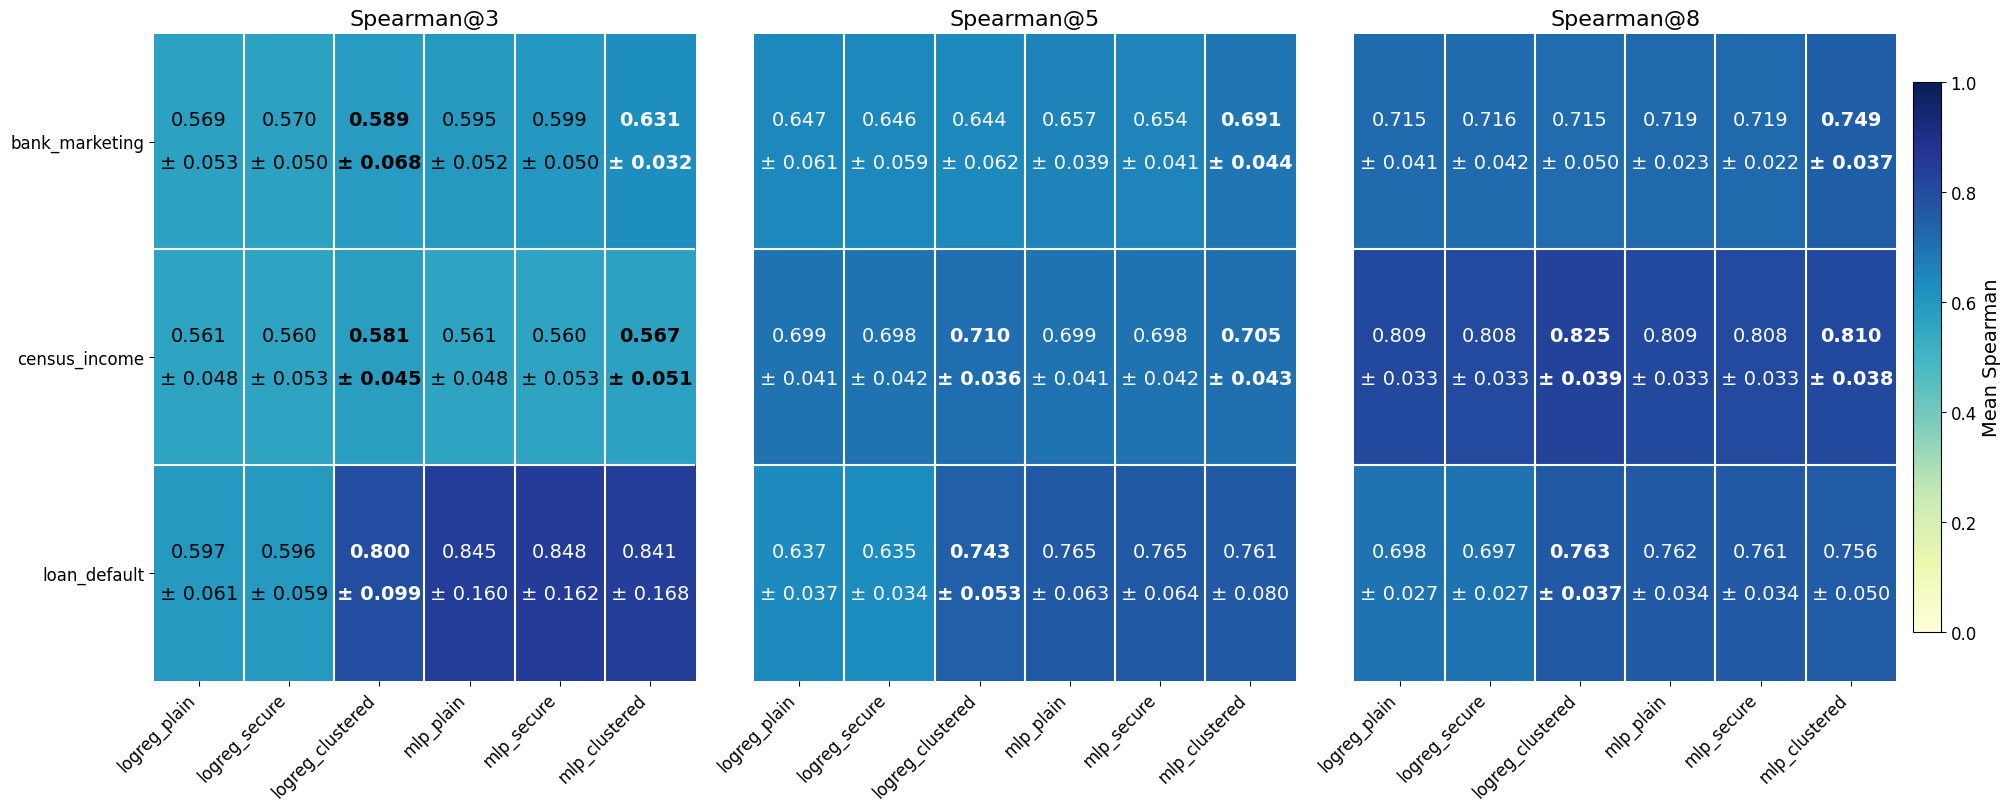

PosixPath('/gpfs/helios/home/kelemnegasi/fed-xai/fed-perso-xai/figure/summary/aggregate_summary_heatmap')

In [11]:
FIGURE_SUMMARY_DIR = REPO_ROOT / "figure" / "summary"
FIGURE_SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

metric_specs = [
    ("spearman_at_3", "Spearman@3"),
    ("spearman_at_5", "Spearman@5"),
    ("spearman_at_8", "Spearman@8"),
]
dataset_order = sorted(agg_summary_df["dataset"].unique())
dataset_display_names = {
    "cencus_income": "census income",
}
mode_order = ["plain", "secure", "clustered"]
model_order = ["logreg", "mlp"]
column_order = [f"{model}_{mode}" for model in model_order for mode in mode_order]

plot_df = agg_summary_df.copy()
plot_df["model_mode"] = plot_df["model_name"] + "_" + plot_df["mode"]

fig, axes = plt.subplots(
    1,
    len(metric_specs),
    figsize=(20, 8),
    gridspec_kw={"wspace": 0.03},
    constrained_layout=True,
)
cmap = plt.get_cmap("YlGnBu")

for panel_idx, (ax, (metric_key, metric_label)) in enumerate(zip(axes, metric_specs)):
    mean_matrix = (
        plot_df.pivot(index="dataset", columns="model_mode", values=f"{metric_key}_mean")
        .reindex(index=dataset_order, columns=column_order)
    )
    std_matrix = (
        plot_df.pivot(index="dataset", columns="model_mode", values=f"{metric_key}_std")
        .reindex(index=dataset_order, columns=column_order)
    )

    image = ax.imshow(mean_matrix.to_numpy(), cmap=cmap, vmin=0.0, vmax=1.0, aspect="auto")
    ax.set_title(metric_label)
    ax.set_xticks(range(len(column_order)))
    ax.set_xticklabels(column_order, rotation=45, ha="right")
    ax.set_yticks(range(len(dataset_order)))
    if panel_idx == 0:
        ax.set_yticklabels([
            dataset_display_names.get(dataset_name, dataset_name)
            for dataset_name in dataset_order
        ])
    else:
        ax.set_yticklabels([])
        ax.tick_params(axis="y", length=0)

    for row_idx, dataset_name in enumerate(dataset_order):
        for col_idx, model_mode in enumerate(column_order):
            mean_val = mean_matrix.loc[dataset_name, model_mode]
            std_val = std_matrix.loc[dataset_name, model_mode]
            label = f"{mean_val:.3f}\n\n± {std_val:.3f}"
            text_color = "white" if mean_val >= 0.6 else "black"

            is_clustered_better = False
            if model_mode.endswith("_clustered"):
                model_name = model_mode.rsplit("_", 1)[0]
                secure_mean = mean_matrix.loc[dataset_name, f"{model_name}_secure"]
                is_clustered_better = mean_val > secure_mean

            ax.text(
                col_idx,
                row_idx,
                label,
                ha="center",
                va="center",
                color=text_color,
                fontsize=14,
                linespacing=1.15,
                fontweight="bold" if is_clustered_better else "normal",
            )

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([x - 0.5 for x in range(1, len(column_order))], minor=True)
    ax.set_yticks([y - 0.5 for y in range(1, len(dataset_order))], minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.5)
    ax.tick_params(which="minor", bottom=False, left=False)

fig.colorbar(image, ax=axes, shrink=0.85, pad=0.01, label="Mean Spearman")
figure_base = FIGURE_SUMMARY_DIR / "aggregate_summary_heatmap"
for suffix in ["png", "svg", "pdf"]:
    fig.savefig(figure_base.with_suffix(f".{suffix}"), bbox_inches="tight", dpi=300)

plt.show()
figure_base


## Model-Only Aggregation

This view collapses across datasets and federated configurations, and reports the aggregate mean and standard deviation by `model + mode` only. Use this table to check abstract-level summary numbers.


In [12]:
model_only_agg_df = (
    all_results_df
    .groupby(["model_name", "mode"], dropna=False)
    .agg(
        run_count=("alpha", "size"),
        dataset_count=("dataset", "nunique"),
        spearman_at_3_mean=("spearman_at_3", "mean"),
        spearman_at_3_std=("spearman_at_3", "std"),
        spearman_at_5_mean=("spearman_at_5", "mean"),
        spearman_at_5_std=("spearman_at_5", "std"),
        spearman_at_8_mean=("spearman_at_8", "mean"),
        spearman_at_8_std=("spearman_at_8", "std"),
    )
    .reset_index()
    .sort_values(["model_name", "mode"])
    .reset_index(drop=True)
)

model_only_agg_df


,model_name,mode,run_count,dataset_count,spearman_at_3_mean,spearman_at_3_std,spearman_at_5_mean,spearman_at_5_std,spearman_at_8_mean,spearman_at_8_std
0,logreg,clustered,32,3,0.664795,0.128644,0.705831,0.061900,0.774228,0.059699
1,logreg,plain,32,3,0.576647,0.055276,0.662680,0.052493,0.744033,0.060861
2,logreg,secure,32,3,0.575789,0.055213,0.661372,0.051577,0.743664,0.060811
3,mlp,clustered,32,3,0.685480,0.163569,0.722560,0.065669,0.774389,0.049794
4,mlp,plain,32,3,0.676036,0.168192,0.713151,0.065632,0.768746,0.047047
5,mlp,secure,32,3,0.677573,0.170554,0.711818,0.066965,0.768422,0.046693


In [13]:
abstract_check_df = model_only_agg_df.copy()
for col in [
    "spearman_at_3_mean", "spearman_at_3_std",
    "spearman_at_5_mean", "spearman_at_5_std",
    "spearman_at_8_mean", "spearman_at_8_std",
]:
    abstract_check_df[col] = abstract_check_df[col].round(3)

abstract_check_df


,model_name,mode,run_count,dataset_count,spearman_at_3_mean,spearman_at_3_std,spearman_at_5_mean,spearman_at_5_std,spearman_at_8_mean,spearman_at_8_std
0,logreg,clustered,32,3,0.665,0.129,0.706,0.062,0.774,0.060
1,logreg,plain,32,3,0.577,0.055,0.663,0.052,0.744,0.061
2,logreg,secure,32,3,0.576,0.055,0.661,0.052,0.744,0.061
3,mlp,clustered,32,3,0.685,0.164,0.723,0.066,0.774,0.050
4,mlp,plain,32,3,0.676,0.168,0.713,0.066,0.769,0.047
5,mlp,secure,32,3,0.678,0.171,0.712,0.067,0.768,0.047


## Model-Wise Bar Plots

This section visualizes the `model_only_agg_df` summary as grouped bar plots. Each panel corresponds to one model, colors separate the aggregation modes, and the x-axis shows `Spearman@3`, `Spearman@5`, and `Spearman@8`.


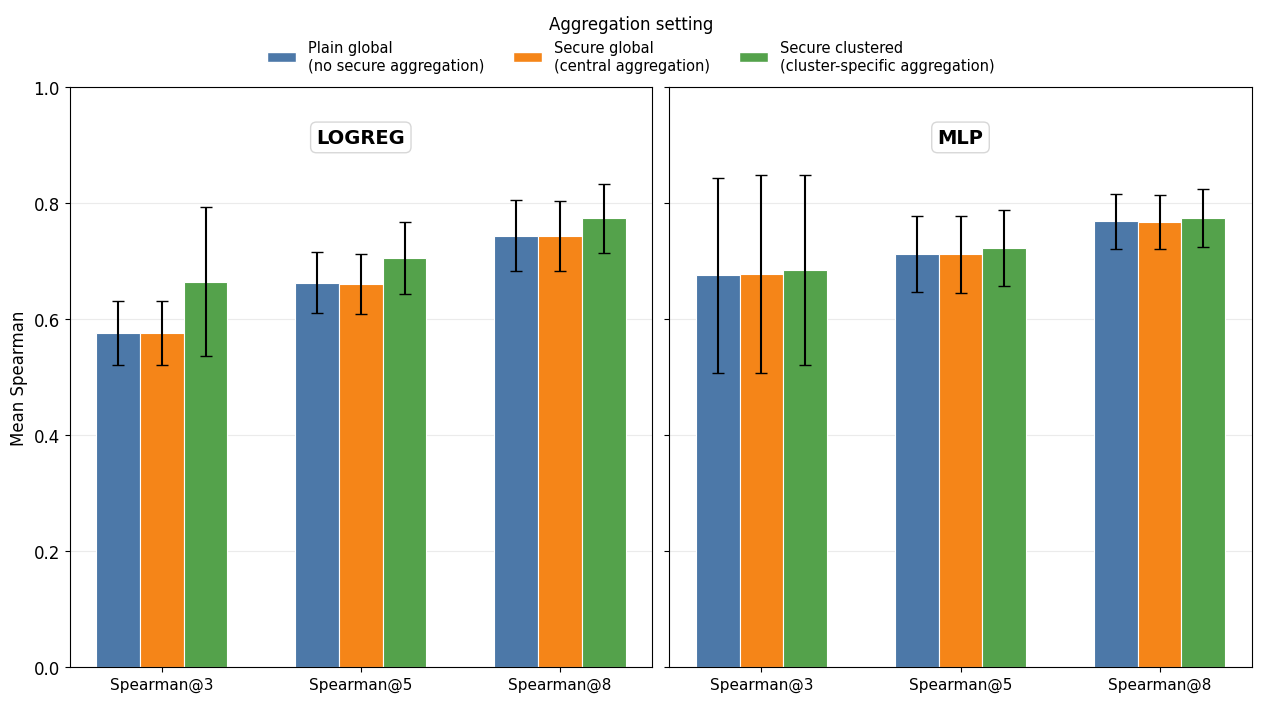

PosixPath('/gpfs/helios/home/kelemnegasi/fed-xai/fed-perso-xai/figure/summary/model_only_aggregation_barplot')

In [14]:
from matplotlib.patches import Patch

bar_metric_specs = [
    ("spearman_at_3", "Spearman@3"),
    ("spearman_at_5", "Spearman@5"),
    ("spearman_at_8", "Spearman@8"),
]

bar_mode_order = ["plain", "secure", "clustered"]
bar_model_order = ["logreg", "mlp"]

bar_colors = {
    "plain": "#4C78A8",
    "secure": "#F58518",
    "clustered": "#54A24B",
}

legend_labels = {
    "plain": "Plain global\n(no secure aggregation)",
    "secure": "Secure global\n(central aggregation)",
    "clustered": "Secure clustered\n(cluster-specific aggregation)",
}

fig, axes = plt.subplots(
    1,
    len(bar_model_order),
    figsize=(12.5, 6.2),
    sharey=True,
    constrained_layout=True,
)

bar_width = 0.22
x_positions = list(range(len(bar_metric_specs)))

for ax, model_name in zip(axes, bar_model_order):
    model_frame = (
        model_only_agg_df.loc[model_only_agg_df["model_name"] == model_name]
        .set_index("mode")
        .reindex(bar_mode_order)
    )

    for mode_idx, mode in enumerate(bar_mode_order):
        offsets = [x + (mode_idx - 1) * bar_width for x in x_positions]

        heights = [
            model_frame.loc[mode, f"{metric_key}_mean"]
            for metric_key, _ in bar_metric_specs
        ]

        errors = [
            model_frame.loc[mode, f"{metric_key}_std"]
            for metric_key, _ in bar_metric_specs
        ]

        ax.bar(
            offsets,
            heights,
            width=bar_width,
            color=bar_colors[mode],
            label=legend_labels[mode],
            yerr=errors,
            capsize=4,
            edgecolor="white",
            linewidth=0.8,
        )

    ax.text(
    0.5,                 # centered horizontally
    0.93,                # inside plot near the top
    model_name.upper(),
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=14,
    fontweight="bold",
    color="black",
    bbox=dict(
        facecolor="white",
        edgecolor="lightgray",
        alpha=0.9,
        boxstyle="round,pad=0.3",
    ),
    zorder=10,
)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([label for _, label in bar_metric_specs], fontsize=11)
    ax.set_ylim(0.0, 1.0)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

axes[0].set_ylabel("Mean Spearman", fontsize=12)

legend_handles = [
    Patch(
        facecolor=bar_colors[mode],
        edgecolor="white",
        label=legend_labels[mode],
    )
    for mode in bar_mode_order
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.12),
    fontsize=10.5,
    title="Aggregation setting",
    title_fontsize=12,
)

model_bar_base = FIGURE_SUMMARY_DIR / "model_only_aggregation_barplot"

for suffix in ["png", "svg", "pdf"]:
    fig.savefig(
        model_bar_base.with_suffix(f".{suffix}"),
        bbox_inches="tight",
        dpi=300,
    )

plt.show()
model_bar_base

## Detailed Secure-vs-Clustered Heatmaps

This section loads the selected `report/<run_id>/.../evaluation_summary.json` files directly, compares `secure` and `clustered` aggregate Spearman values, and annotates each cell with the percentage and count of clients for which `clustered > secure`. One 3-panel figure is created per `model + dataset`, with columns for `Spearman@3`, `Spearman@5`, and `Spearman@8`, and each figure is saved to `figure/detailed_reports/` as PNG, SVG, and PDF.


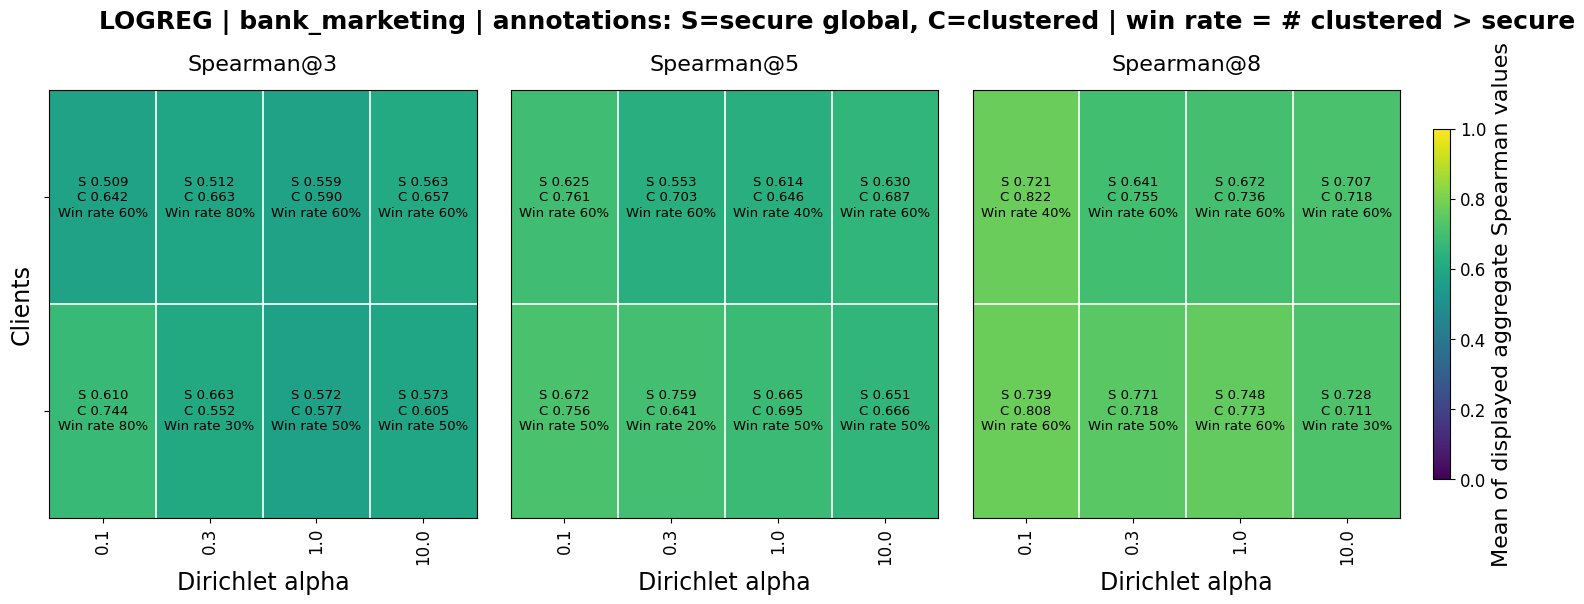

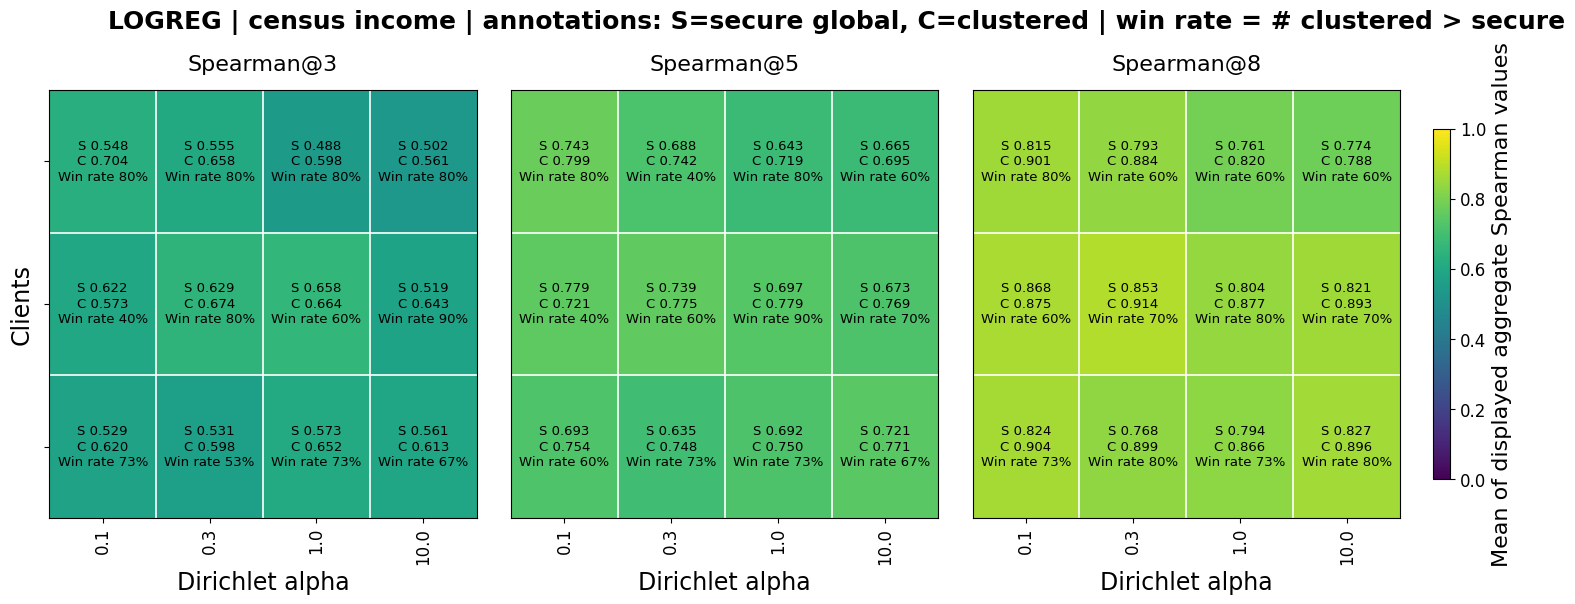

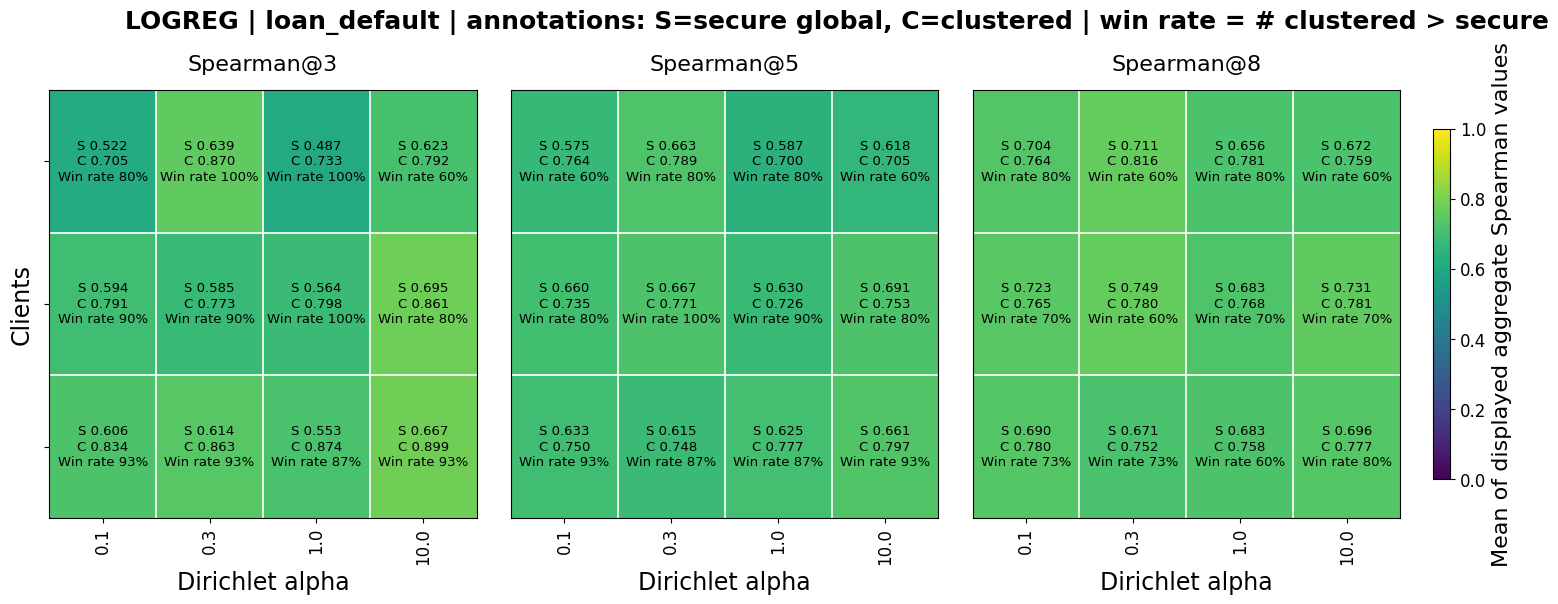

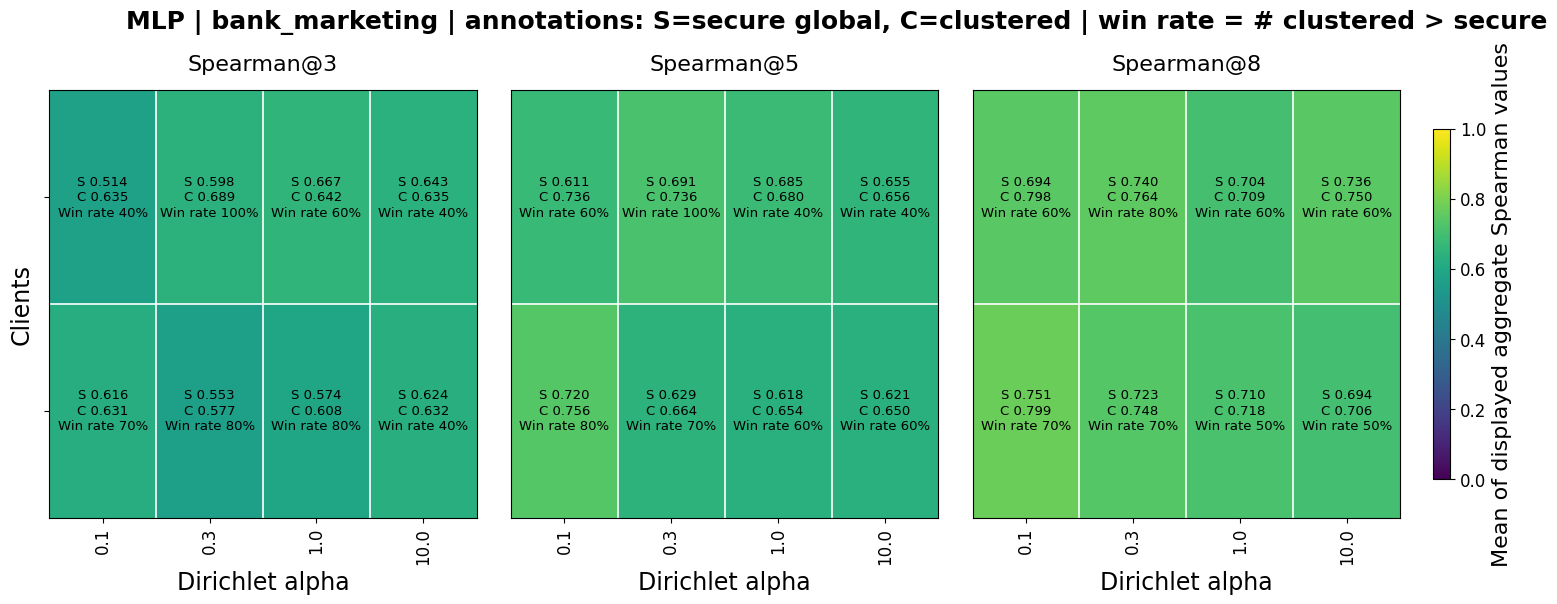

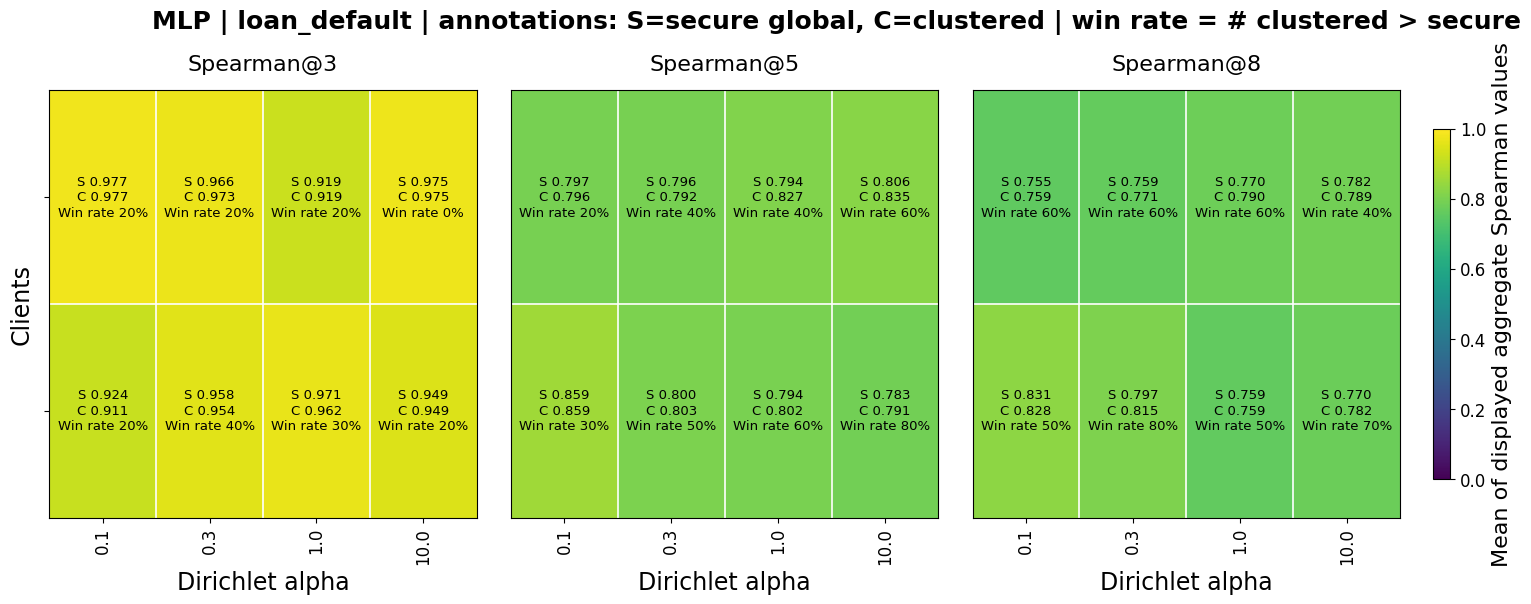

['figure/detailed_reports/logreg_bank_marketing_clustered_vs_secure_client_heatmaps',
 'figure/detailed_reports/logreg_cencus_income_clustered_vs_secure_client_heatmaps',
 'figure/detailed_reports/logreg_loan_default_clustered_vs_secure_client_heatmaps',
 'figure/detailed_reports/mlp_bank_marketing_clustered_vs_secure_client_heatmaps',
 'figure/detailed_reports/mlp_loan_default_clustered_vs_secure_client_heatmaps']

In [17]:
FIGURE_DETAILED_DIR = REPO_ROOT / "figure" / "detailed_reports"
FIGURE_DETAILED_DIR.mkdir(parents=True, exist_ok=True)

detailed_metric_specs = [
    ("spearman_at_3", "Spearman@3"),
    ("spearman_at_5", "Spearman@5"),
    ("spearman_at_8", "Spearman@8"),
]

RUN_ID_PATTERN = re.compile(
    r"^federated-training-(?P<dataset>.+?)-\d{8}t\d+\+\d+-(?P<model>logreg|mlp_classifier)-(?P<client_count>\d+)clients-alpha(?P<alpha>[0-9.]+)-seed(?P<seed>\d+)-(?P<tag>[a-f0-9]+)$"
)


def parse_run_id_metadata(run_id: str) -> dict[str, object]:
    match = RUN_ID_PATTERN.match(run_id)
    if match is None:
        raise ValueError(f"Could not parse run_id: {run_id}")

    parts = match.groupdict()

    return {
        "run_id": run_id,
        "dataset": parts["dataset"],
        "model_name": "mlp" if parts["model"] == "mlp_classifier" else parts["model"],
        "client_count": int(parts["client_count"]),
        "alpha": float(parts["alpha"]),
        "alpha_label": parts["alpha"],
    }


detailed_records = []
missing_detailed_runs = []

for run_id in all_run_ids:
    secure_path = REPORT_ROOT / run_id / "secure" / "evaluation_summary.json"
    clustered_path = REPORT_ROOT / run_id / "clustered" / "evaluation_summary.json"

    if not secure_path.exists() or not clustered_path.exists():
        missing_detailed_runs.append(run_id)
        continue

    secure_payload = json.loads(secure_path.read_text(encoding="utf-8"))
    clustered_payload = json.loads(clustered_path.read_text(encoding="utf-8"))

    run_meta = parse_run_id_metadata(run_id)

    secure_clients = {
        client["client_id"]: client
        for client in secure_payload.get("clients", [])
        if client.get("client_id") is not None
    }

    clustered_clients = {
        client["client_id"]: client
        for client in clustered_payload.get("clients", [])
        if client.get("client_id") is not None
    }

    shared_client_ids = sorted(set(secure_clients) & set(clustered_clients))

    for metric_key, metric_label in detailed_metric_specs:

        comparable_client_ids = [
            client_id
            for client_id in shared_client_ids
            if secure_clients[client_id].get(metric_key) is not None
            and clustered_clients[client_id].get(metric_key) is not None
        ]

        improved_client_count = sum(
            clustered_clients[client_id][metric_key]
            > secure_clients[client_id][metric_key]
            for client_id in comparable_client_ids
        )

        compared_client_count = len(comparable_client_ids)

        secure_aggregate = secure_payload.get("aggregate", {}).get(metric_key)
        clustered_aggregate = clustered_payload.get("aggregate", {}).get(metric_key)

        display_mean = None
        if secure_aggregate is not None and clustered_aggregate is not None:
            display_mean = (secure_aggregate + clustered_aggregate) / 2

        detailed_records.append({
            **run_meta,
            "metric_key": metric_key,
            "metric_label": metric_label,
            "secure_aggregate": secure_aggregate,
            "clustered_aggregate": clustered_aggregate,
            "display_mean": display_mean,
            "improved_client_count": improved_client_count,
            "compared_client_count": compared_client_count,
            "improved_client_share": (
                None
                if compared_client_count == 0
                else improved_client_count / compared_client_count
            ),
        })

detailed_report_df = (
    pd.DataFrame(detailed_records)
    .sort_values(
        ["model_name", "dataset", "client_count", "alpha", "metric_key"]
    )
    .reset_index(drop=True)
)

detailed_dataset_display_names = {
    "cencus_income": "census income",
}

saved_detailed_figures = []

for (model_name, dataset_name), combo_df in detailed_report_df.groupby(
    ["model_name", "dataset"],
    dropna=False,
):

    client_order = sorted(combo_df["client_count"].unique())
    alpha_order = sorted(combo_df["alpha"].unique())

    alpha_label_map = (
        combo_df[["alpha", "alpha_label"]]
        .drop_duplicates()
        .sort_values("alpha")
        .set_index("alpha")["alpha_label"]
        .to_dict()
    )

    fig, axes = plt.subplots(
        1,
        len(detailed_metric_specs),
        figsize=(21, 6.2),
        sharey=True,
    )

    fig.subplots_adjust(
        top=0.80,
        wspace=0.08,
        right=0.90,
    )

    cmap = plt.get_cmap("viridis")
    image = None

    for panel_idx, (ax, (metric_key, metric_label)) in enumerate(
        zip(axes, detailed_metric_specs)
    ):

        metric_df = combo_df.loc[
            combo_df["metric_key"] == metric_key
        ]

        mean_matrix = (
            metric_df.pivot(
                index="client_count",
                columns="alpha",
                values="display_mean",
            )
            .reindex(index=client_order, columns=alpha_order)
        )

        secure_matrix = (
            metric_df.pivot(
                index="client_count",
                columns="alpha",
                values="secure_aggregate",
            )
            .reindex(index=client_order, columns=alpha_order)
        )

        clustered_matrix = (
            metric_df.pivot(
                index="client_count",
                columns="alpha",
                values="clustered_aggregate",
            )
            .reindex(index=client_order, columns=alpha_order)
        )

        improved_count_matrix = (
            metric_df.pivot(
                index="client_count",
                columns="alpha",
                values="improved_client_count",
            )
            .reindex(index=client_order, columns=alpha_order)
        )

        compared_count_matrix = (
            metric_df.pivot(
                index="client_count",
                columns="alpha",
                values="compared_client_count",
            )
            .reindex(index=client_order, columns=alpha_order)
        )

        image = ax.imshow(
            mean_matrix.to_numpy(dtype=float),
            cmap=cmap,
            vmin=0.0,
            vmax=1.0,
            aspect="auto",
        )

        ax.set_title(
            metric_label,
            fontsize=16,
            pad=14,
        )

        ax.set_xticks(range(len(alpha_order)))
        ax.set_xticklabels(
            [alpha_label_map[alpha] for alpha in alpha_order],
            fontsize=12,
            rotation=90,
        )

        ax.set_xlabel(
            "Dirichlet alpha",
            fontsize=17,
        )

        ax.set_yticks(range(len(client_order)))

        if panel_idx == 0:
            ax.set_yticklabels(client_order, fontsize=12)
            ax.set_ylabel("Clients", fontsize=17)
        else:
            ax.set_yticklabels([])
            ax.tick_params(axis="y", length=0)

        for row_idx, client_count in enumerate(client_order):
            for col_idx, alpha in enumerate(alpha_order):

                secure_val = secure_matrix.loc[client_count, alpha]
                clustered_val = clustered_matrix.loc[client_count, alpha]

                improved_count = improved_count_matrix.loc[
                    client_count,
                    alpha,
                ]

                compared_count = compared_count_matrix.loc[
                    client_count,
                    alpha,
                ]

                if pd.isna(secure_val) or pd.isna(clustered_val):
                    label = "missing"

                else:
                    improved_pct = (
                        100.0 * improved_count / compared_count
                        if compared_count
                        else float("nan")
                    )

                    label = (
                        f"S {secure_val:.3f}\n"
                        f"C {clustered_val:.3f}\n"
                        f"Win rate {improved_pct:.0f}%"
                    )

                display_val = mean_matrix.loc[client_count, alpha]

                text_color = (
                    "white"
                    if pd.notna(display_val) and display_val < 0.45
                    else "black"
                )

                ax.text(
                    col_idx,
                    row_idx,
                    label,
                    ha="center",
                    va="center",
                    fontsize=9.5,
                    linespacing=1.25,
                    color=text_color,
                )

        ax.set_xticks(
            [x - 0.5 for x in range(1, len(alpha_order))],
            minor=True,
        )

        ax.set_yticks(
            [y - 0.5 for y in range(1, len(client_order))],
            minor=True,
        )

        ax.grid(
            which="minor",
            color="white",
            linewidth=1.2,
        )

        ax.tick_params(
            which="minor",
            bottom=False,
            left=False,
        )

    dataset_display_name = detailed_dataset_display_names.get(dataset_name, dataset_name)

    fig.suptitle(
        (
            f"{model_name.upper()} | {dataset_display_name} | "
            f"annotations: S=secure global, C=clustered | "
            f"win rate = # clustered > secure"
        ),
        fontsize=18,
        y=0.93,
        fontweight="bold",
    )

    cbar = fig.colorbar(
        image,
        ax=axes,
        shrink=0.82,
        pad=0.02,
    )

    cbar.set_label(
        "Mean of displayed aggregate Spearman values",
        fontsize=16,
    )

    cbar.ax.tick_params(labelsize=12)

    figure_base = (
        FIGURE_DETAILED_DIR
        / f"{model_name}_{dataset_name}_clustered_vs_secure_client_heatmaps"
    )

    for suffix in ["png", "svg", "pdf"]:
        fig.savefig(
            figure_base.with_suffix(f".{suffix}"),
            bbox_inches="tight",
            dpi=300,
        )

    plt.show()
    plt.close(fig)

    saved_detailed_figures.append(
        str(figure_base.relative_to(REPO_ROOT))
    )

saved_detailed_figures